# HOMER: scalar block means and inference

This notebook examines inference after smooth aggregation of independent block means. A fixed pseudo-Huber threshold defines a block target that need not equal the population mean. The simulations separate target mismatch from the accuracy of the sandwich approximation and from the effect of having few blocks.

The saved experiment has 26 cells and 2,000 replications per cell. Its Bernoulli targets use the entire binomial support; Gaussian cells provide a symmetric reference and fixed-block sensitivity checks.


## Choose the results to read

`paper` reads the compact manuscript results. Set `MODE` to `smoke` for a short run or `full` for the manuscript replication counts. Every mode draws figures directly from its selected results inside this notebook, without writing image files or requiring TeX. Fresh numerical results go to `runs/`.

The committed outputs show `paper` mode. After changing `MODE`, run all cells to refresh the tables and figures. Smoke curves check execution and are too imprecise for scientific conclusions.


In [1]:
MODE = "paper"  # "paper", "smoke", or "full"
STUDIES = ['scalar']


In [2]:
from pathlib import Path
import subprocess
import sys

import pandas as pd
from IPython.display import Markdown, display

%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png")
import matplotlib.pyplot as plt
import numpy as np

ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "results").is_dir() and (p / "notebooks").is_dir()),
    None,
)
if ROOT is None:
    raise RuntimeError("Open this notebook from the repository root or notebooks directory.")
if MODE not in {"paper", "smoke", "full"}:
    raise ValueError("MODE must be 'paper', 'smoke', or 'full'.")

sys.path.insert(0, str(ROOT / "code"))
from notebook_plots import (
    scalar_coverage, functional_coverage, functional_stability,
    covariance_heatmaps, wearable_stability,
)

if MODE == "paper":
    RESULTS = ROOT / "results"
    display(Markdown("**Reading the saved manuscript results.** No experiments are rerun."))
else:
    subprocess.run(
        [sys.executable, str(ROOT / "code" / "reproduce.py"), "--mode", MODE,
         "--study", *STUDIES, "--resume"],
        cwd=ROOT, check=True,
    )
    RESULTS = ROOT / "runs" / MODE / "results"
    display(Markdown(f"**Reading {MODE} results** from `runs/{MODE}/results/`."))

pd.set_option("display.max_columns", 12)
pd.set_option("display.precision", 4)

def show_figure(figure):
    display(figure)
    plt.close(figure)


**Reading the saved manuscript results.** No experiments are rerun.

## Compare population-mean and block-target coverage

The two rows per setting compare the same estimated-variance interval against two targets. Monte Carlo intervals quantify uncertainty in a simulated coverage proportion; they are not confidence intervals for either target.


In [3]:
scalar = pd.read_csv(RESULTS / "scalar_summary.csv")
coverage = scalar.loc[
    scalar["metric"].isin(["plugin_mean_covered", "plugin_target_covered"]),
    ["distribution", "schedule", "k", "m", "lambda", "metric", "reps",
     "coverage", "mc_low", "mc_high"],
]
display(coverage.loc[coverage["schedule"].isin(["slow", "boundary", "many"])]
        .reset_index(drop=True))


,distribution,schedule,k,m,lambda,metric,reps,coverage,mc_low,mc_high
0,bernoulli,slow,16,256,1.0,plugin_mean_covered,2000,0.9150,0.9020,0.9264
1,bernoulli,slow,16,256,1.0,plugin_target_covered,2000,0.9160,0.9030,0.9274
2,bernoulli,boundary,64,64,1.0,plugin_mean_covered,2000,0.9355,0.9239,0.9455
3,bernoulli,boundary,64,64,1.0,plugin_target_covered,2000,0.9485,0.9379,0.9574
4,bernoulli,many,256,16,1.0,plugin_mean_covered,2000,0.8130,0.7953,0.8295
5,bernoulli,many,256,16,1.0,plugin_target_covered,2000,0.9495,0.9390,0.9583
6,bernoulli,slow,32,1024,1.0,plugin_mean_covered,2000,0.9325,0.9207,0.9427
7,bernoulli,slow,32,1024,1.0,plugin_target_covered,2000,0.9310,0.9190,0.9413
8,bernoulli,boundary,128,256,1.0,plugin_mean_covered,2000,0.9395,0.9282,0.9491
9,bernoulli,boundary,128,256,1.0,plugin_target_covered,2000,0.9475,0.9368,0.9564


## Inspect the numerical targets and fit diagnostics

The finite-sample block targets are evaluated before the Monte Carlo comparisons. A small score residual checks the target calculation. Inference records also retain solver, covariance, and certificate failures rather than dropping them.


In [4]:
targets = pd.read_csv(RESULTS / "scalar_targets.csv")
display(targets[["m", "p", "lambda", "theta", "V", "score_residual"]]
        .drop_duplicates().reset_index(drop=True))

# Failure counts repeat across coverage metrics; count each experimental cell once.
checks = scalar.drop_duplicates("cell")
display(checks[["solver_failures", "covariance_failures", "certificate_failures"]]
        .sum().rename("total").to_frame())


,m,p,lambda,theta,V,score_residual
0,256,0.10,1.0,-1.0474e-03,1.0795,4.7705e-18
1,64,0.10,1.0,-4.2144e-03,1.0811,6.9389e-18
2,16,0.10,1.0,-1.7330e-02,1.1109,2.7756e-17
3,1024,0.10,1.0,-2.6147e-04,1.0792,9.3817e-18
4,32,0.10,1.0,-8.4993e-03,1.0824,6.8001e-16
5,4096,0.10,1.0,-6.5344e-05,1.0791,1.7094e-17
6,512,0.10,1.0,-5.2320e-04,1.0793,4.1572e-18
7,256,NaN,1.0,0.0000e+00,1.0790,0.0000e+00
8,1024,NaN,1.0,0.0000e+00,1.0790,0.0000e+00
9,4096,NaN,1.0,0.0000e+00,1.0790,0.0000e+00


,total
solver_failures,0
covariance_failures,0
certificate_failures,0


## Coverage across block schedules

These panels correspond to the scalar coverage comparison in Figure 1. They use the selected mode's estimates and Monte Carlo intervals; the horizontal line marks nominal coverage. The functional efficiency and contamination panels are shown in `functional.ipynb`.


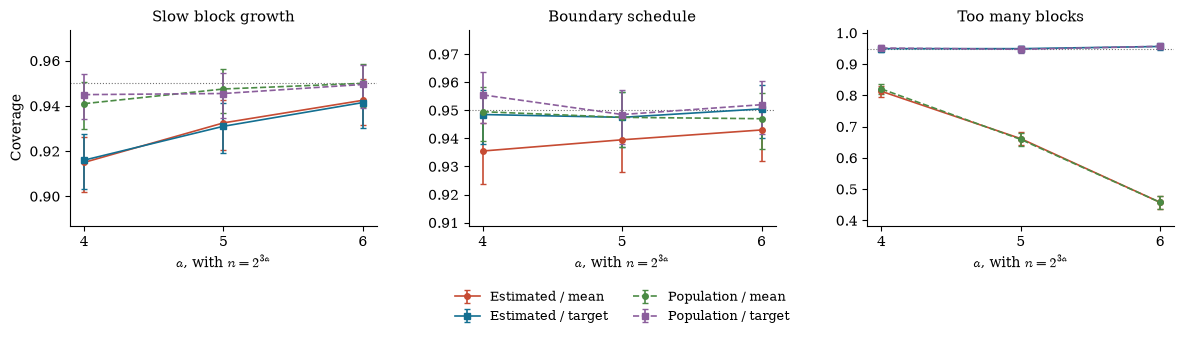

In [5]:
show_figure(scalar_coverage(scalar))


## Scope

These results concern fixed deterministic thresholds and block means. They do not provide an adaptive-threshold inference theorem. The settings with few blocks and those with a substantial target difference are part of the comparison, including their undercoverage.

For independent high-precision target checks, run `python code/reproduce.py --mode full --study scalar --audit-targets`. See `../docs/DATA_SOURCES.md` and the saved manifests for the exact seeds, formulas, and computational scope.
